# Treinamento Completo - Todas as Imagens MoNuSeg

Este notebook executa o **treinamento da MarkerNet com todas as 44 imagens** (30 de treino + 14 de teste) do MoNuSeg, usando o mesmo fluxo validado no teste end-to-end (`test_e2e_pipeline.ipynb`), porém em escala completa:

1. **Leitura** das 44 imagens (configs `monuseg_training` + `monuseg_test`) + máscaras de ground truth;
2. **Pré-processamento** (Cellpose + RGBA + mapa de distância) para todas as imagens;
3. **Preparação dos batches** (mapa de distância já calculado no pré-processamento, split 80/20);
4. **Treinamento** da MarkerNet através da rede final congelada (ScribblePrompt);
5. **Avaliação** (curvas de loss, validação e checkpoint).

Fluxo do pipeline de treinamento:

```
imagem + RGBA → MarkerStep (MarkerNet diferenciável) → markers
→ FrozenSegmentationStep (ScribblePrompt congelado) → segmentation
→ LossComposer (dice + rmse + size) → backward até a MarkerNet
```

> **Configurações do treinamento:** 50 épocas, split 80/20 (35 treino / 9 validação), resolução original das imagens (1000×1000) e checkpoint salvo ao final.

## 0. Setup

**Colab:** instale as dependências na célula abaixo (`requirements.txt` fixa todas as versões; torch/torchvision preservam a build GPU do Colab).

**Local:** garanta que o `.venv` esteja ativo com as dependências instaladas.

In [30]:
# Clone the repository containing the project code (apenas no Colab)
import sys
import os
repo_dir = 'cell-fuzzy-seg'
# if not os.path.exists(repo_dir):
#     !git clone --branch homolog https://github.com/Pedro-io/cell-fuzzy-seg.git
# Local: pule esta célula e rode o notebook a partir da raiz do projeto.
%cd {repo_dir}
sys.path.append(f"/content/{repo_dir}")

[Errno 2] No such file or directory: 'cell-fuzzy-seg'
/content/cell-fuzzy-seg/cell-fuzzy-seg


In [31]:
# Instala as dependências (apenas no Colab / primeira execução)
import sys

if "google.colab" in sys.modules:
    get_ipython().system("python -m pip install -r requirements.txt -q")
else:
    print("Ambiente local: verifique se as dependências estão instaladas no .venv.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 23.3 MB/s eta 0:00:00:00:0100:01


## 1. Imports e dispositivo

In [32]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Garante que a raiz do projeto esteja no path (robusto para upload/clone no Colab)
ROOT = os.getcwd()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from src.data.load.monuseg_dataset import MonusegDataset
from src.pipeline.preprocessing_pipeline import PreprocessingPipeline
from src.pipeline.steps.preprocessing.cellpose_step import CellposeStep
from src.pipeline.steps.preprocessing.rgba_step import RGBAStep
from src.pipeline.steps.preprocessing.distance_map_step import DistanceMapStep
from src.pipeline.training_pipeline import TrainingPipeline
from src.pipeline.steps.inference.marker_step import MarkerStep
from src.pipeline.steps.inference.frozen_segmentation_step import FrozenSegmentationStep
from src.models.networks.marker_unet import MarkerUNet
from src.models.configs.marker_unet_config import UNET_CONFIG
from src.models.networks.final_segmentation.base_final_segmentation import BaseFinalSegmentation
from src.losses.terms import DiceTerm, RMSETerm, SizeTerm
from src.losses.loss_composer import LossComposer
from src.training.trainer import Trainer
from src.training.training_loop import TrainingLoop

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
print(f"Device: {DEVICE}")

Device: cuda


## 2. Leitura - todas as imagens MoNuSeg

Carregamos as **30 imagens** do dataset de treino junto com as máscaras de ground truth (convertidas do XML).

In [33]:
train_dataset = MonusegDataset(dataset_name="monuseg", config_key="monuseg_training")
test_dataset = MonusegDataset(dataset_name="monuseg", config_key="monuseg_test")
print(f"Treino: {len(train_dataset)} imagens | Teste: {len(test_dataset)} imagens")

# Combina as duas configs (treino + teste) para ter mais dados para treinar.
samples = [train_dataset[i] for i in range(len(train_dataset))]
samples += [test_dataset[i] for i in range(len(test_dataset))]
ids = [s["id"] for s in samples]
print(f"Total de amostras (treino+teste): {len(samples)}")
print("ids:", ids)
print("image:", samples[0]["image"].shape, samples[0]["image"].dtype)
print("ground_truth:", samples[0]["ground_truth"].shape, samples[0]["ground_truth"].dtype,
      "classes:", np.unique(samples[0]["ground_truth"]))

2026-08-10 12:17:08.618 | DEBUG    | src.data.load.monuseg_dataset:_get_file_pairs:99 - Getting file pairs from: image_dir=data_source/MoNuSegTrainingData/Tissue_Images, mask_dir=data_source/MoNuSegTrainingData/Annotations
2026-08-10 12:17:08.619 | DEBUG    | src.data.load.monuseg_dataset:_load_image:54 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-18-5592-01Z-00-DX1.tif
2026-08-10 12:17:08.663 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:76 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-18-5592-01Z-00-DX1.xml


Total de imagens no dataset: 30


2026-08-10 12:17:08.991 | DEBUG    | src.data.load.monuseg_dataset:_load_image:54 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-21-5784-01Z-00-DX1.tif
2026-08-10 12:17:09.032 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:76 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-21-5784-01Z-00-DX1.xml
2026-08-10 12:17:09.257 | DEBUG    | src.data.load.monuseg_dataset:_load_image:54 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-21-5786-01Z-00-DX1.tif
2026-08-10 12:17:09.304 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:76 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TCGA-21-5786-01Z-00-DX1.xml
2026-08-10 12:17:09.514 | DEBUG    | src.data.load.monuseg_dataset:_load_image:54 - Loading image: data_source/MoNuSegTrainingData/Tissue_Images/TCGA-38-6178-01Z-00-DX1.tif
2026-08-10 12:17:09.568 | DEBUG    | src.data.load.monuseg_dataset:_load_mask:76 - Loading mask: data_source/MoNuSegTrainingData/Annotations/TC

ids: ['TCGA-18-5592-01Z-00-DX1', 'TCGA-21-5784-01Z-00-DX1', 'TCGA-21-5786-01Z-00-DX1', 'TCGA-38-6178-01Z-00-DX1', 'TCGA-49-4488-01Z-00-DX1', 'TCGA-50-5931-01Z-00-DX1', 'TCGA-A7-A13E-01Z-00-DX1', 'TCGA-A7-A13F-01Z-00-DX1', 'TCGA-AR-A1AK-01Z-00-DX1', 'TCGA-AR-A1AS-01Z-00-DX1', 'TCGA-AY-A8YK-01A-01-TS1', 'TCGA-B0-5698-01Z-00-DX1', 'TCGA-B0-5710-01Z-00-DX1', 'TCGA-B0-5711-01Z-00-DX1', 'TCGA-CH-5767-01Z-00-DX1', 'TCGA-DK-A2I6-01A-01-TS1', 'TCGA-E2-A14V-01Z-00-DX1', 'TCGA-E2-A1B5-01Z-00-DX1', 'TCGA-G2-A2EK-01A-02-TSB', 'TCGA-G9-6336-01Z-00-DX1', 'TCGA-G9-6348-01Z-00-DX1', 'TCGA-G9-6356-01Z-00-DX1', 'TCGA-G9-6362-01Z-00-DX1', 'TCGA-G9-6363-01Z-00-DX1', 'TCGA-HE-7128-01Z-00-DX1', 'TCGA-HE-7129-01Z-00-DX1', 'TCGA-HE-7130-01Z-00-DX1', 'TCGA-KB-A93J-01A-01-TS1', 'TCGA-NH-A8F7-01A-01-TS1', 'TCGA-RD-A8N9-01A-01-TS1']
image: (1000, 1000, 3) uint8
ground_truth: (1000, 1000) uint8 classes: [0 1]


## 3. Pré-processamento - Cellpose + RGBA + mapa de distância (todas as imagens)

Executa a segmentação inicial (Cellpose), monta a imagem RGBA (RGB + alpha da máscara) e calcula o **mapa de distância** a partir do ground truth para **cada uma das 44 imagens**. Em GPU, cada imagem leva alguns segundos.

> **Fallback:** se o Cellpose não estiver disponível (sem GPU), usa o próprio ground truth como máscara de entrada, apenas para validar o restante do fluxo.

In [34]:
# Tenta usar o Cellpose; sem GPU, usa o ground truth como máscara de entrada.
try:
    cellpose_step = CellposeStep()
    preprocess = PreprocessingPipeline([cellpose_step, RGBAStep(), DistanceMapStep()])
    print("Cellpose disponível - executando pré-processamento em todas as imagens...")
except Exception as e:
    print(f"[fallback] Cellpose indisponível: {e}")
    preprocess = None

preprocessed = []
for i, sample in enumerate(samples):
    data = {"image": sample["image"], "ground_truth": sample["ground_truth"], "id": sample["id"]}
    if preprocess is not None:
        data = preprocess.run(data, verbose=False)
    else:
        data["segmentation"] = (sample["ground_truth"] > 0).astype(np.uint8)
        data = RGBAStep()(data)
        data = DistanceMapStep()(data)
    preprocessed.append(data)
    print(f"[{i+1:02d}/{len(samples)}] {sample['id']} | segmentation: {data['segmentation'].shape} | rgba: {data['rgba'].shape} | distance_map: {data['distance_map'].shape}")

2026-08-10 12:17:23.700 | INFO     | src.pipeline.steps.preprocessing.cellpose_step:__init__:58 - [CellposeStep] Running on GPU


Cellpose disponível - executando pré-processamento em todas as imagens...


2026-08-10 12:17:36.166 | DEBUG    | src.pipeline.steps.preprocessing.rgba_step:_build_rgba:75 - Building RGBA image: image shape (1000, 1000, 3), segmentation shape (1000, 1000)
2026-08-10 12:17:36.259 | DEBUG    | src.pipeline.steps.preprocessing.distance_map_step:forward:100 - [DistanceMapStep] Computed distance map with shape (1000, 1000)


[01/30] TCGA-18-5592-01Z-00-DX1 | segmentation: (1000, 1000) | rgba: (1000, 1000, 4) | distance_map: (1000, 1000)


2026-08-10 12:17:48.615 | DEBUG    | src.pipeline.steps.preprocessing.rgba_step:_build_rgba:75 - Building RGBA image: image shape (1000, 1000, 3), segmentation shape (1000, 1000)
2026-08-10 12:17:48.707 | DEBUG    | src.pipeline.steps.preprocessing.distance_map_step:forward:100 - [DistanceMapStep] Computed distance map with shape (1000, 1000)


...

[28/30] TCGA-KB-A93J-01A-01-TS1 | segmentation: (1000, 1000) | rgba: (1000, 1000, 4) | distance_map: (1000, 1000)


2026-08-10 12:22:35.383 | DEBUG    | src.pipeline.steps.preprocessing.rgba_step:_build_rgba:75 - Building RGBA image: image shape (1000, 1000, 3), segmentation shape (1000, 1000)
2026-08-10 12:22:35.485 | DEBUG    | src.pipeline.steps.preprocessing.distance_map_step:forward:100 - [DistanceMapStep] Computed distance map with shape (1000, 1000)


[29/30] TCGA-NH-A8F7-01A-01-TS1 | segmentation: (1000, 1000) | rgba: (1000, 1000, 4) | distance_map: (1000, 1000)


2026-08-10 12:22:46.358 | DEBUG    | src.pipeline.steps.preprocessing.rgba_step:_build_rgba:75 - Building RGBA image: image shape (1000, 1000, 3), segmentation shape (1000, 1000)
2026-08-10 12:22:46.453 | DEBUG    | src.pipeline.steps.preprocessing.distance_map_step:forward:100 - [DistanceMapStep] Computed distance map with shape (1000, 1000)


[30/30] TCGA-RD-A8N9-01A-01-TS1 | segmentation: (1000, 1000) | rgba: (1000, 1000, 4) | distance_map: (1000, 1000)


## 4. Batches de treino e validação (split 80/20)

Montamos os batches a partir das amostras já pré-processadas, **sem resize nem normalização** — resolução e normalização são tratadas pelo pipeline (`RGBAStep`, `DistanceMapStep`) e pelas redes (`MarkerStep`, rede final). O **mapa de distância** já foi calculado pelo `DistanceMapStep` durante o pré-processamento. O split `train_split: 0.8` (35 treino / 9 validação) do `configs/datasets.yml` é aplicado sobre as 44 amostras.

Cada batch contém as chaves esperadas pelo `Trainer` + `LossComposer`.

In [35]:
def build_batch(sample):
    img = sample["image"]
    gt = sample["ground_truth"]

    image_np = img
    if image_np.ndim == 3 and image_np.shape[-1] == 4:
        image_np = image_np[..., :3]
    if image_np.ndim == 2:
        image_np = np.stack([image_np] * 3, axis=-1)
    # Sem resize/normalização aqui: o pipeline (RGBAStep/DistanceMapStep) e as
    # redes (MarkerStep e rede final) já tratam resolução e normalização.
    # Válido porque as imagens MoNuSeg são uniformes (1000×1000); se a resolução
    # variar entre amostras, um resize explícito seria necessário.

    return {
        "id": sample["id"],
        "image": torch.from_numpy(image_np.transpose(2, 0, 1)).float().unsqueeze(0),  # (1,3,H,W)
        "rgba": sample["rgba"],                                                       # (H,W,4) numpy
        "ground_truth": torch.from_numpy(gt.astype(np.float32)[None, None]),          # (1,1,H,W)
        "distance_map": torch.from_numpy(sample["distance_map"][None, None]),        # (1,1,H,W)
    }


batches = [build_batch(s) for s in preprocessed]

# Split 80/20 com embaralhamento determinístico. Usamos um rng local para
# não depender do estado global do numpy (que o Cellpose pode consumir).
rng = np.random.default_rng(42)
train_split = train_dataset.config.get("train_split", 0.8)
n_train = int(train_split * len(batches))
perm = rng.permutation(len(batches))
train_batches = [batches[i] for i in perm[:n_train]]
val_batches = [batches[i] for i in perm[n_train:]]
print("ids de treino:", [b["id"] for b in train_batches])
print("ids de validação:", [b["id"] for b in val_batches])

print(f"total={len(batches)} | treino={len(train_batches)} | validação={len(val_batches)}")
b = train_batches[0]
for k, v in b.items():
    print(k, tuple(v.shape) if hasattr(v, "shape") else v)


ids de treino: ['TCGA-RD-A8N9-01A-01-TS1', 'TCGA-E2-A14V-01Z-00-DX1', 'TCGA-A7-A13F-01Z-00-DX1', 'TCGA-HE-7129-01Z-00-DX1', 'TCGA-HE-7128-01Z-00-DX1', 'TCGA-G9-6362-01Z-00-DX1', 'TCGA-50-5931-01Z-00-DX1', 'TCGA-G9-6356-01Z-00-DX1', 'TCGA-HE-7130-01Z-00-DX1', 'TCGA-AY-A8YK-01A-01-TS1', 'TCGA-G9-6336-01Z-00-DX1', 'TCGA-G9-6348-01Z-00-DX1', 'TCGA-AR-A1AS-01Z-00-DX1', 'TCGA-A7-A13E-01Z-00-DX1', 'TCGA-G2-A2EK-01A-02-TSB', 'TCGA-38-6178-01Z-00-DX1', 'TCGA-18-5592-01Z-00-DX1', 'TCGA-DK-A2I6-01A-01-TS1', 'TCGA-E2-A1B5-01Z-00-DX1', 'TCGA-G9-6363-01Z-00-DX1', 'TCGA-B0-5710-01Z-00-DX1', 'TCGA-B0-5698-01Z-00-DX1', 'TCGA-CH-5767-01Z-00-DX1', 'TCGA-NH-A8F7-01A-01-TS1']
ids de validação: ['TCGA-21-5786-01Z-00-DX1', 'TCGA-49-4488-01Z-00-DX1', 'TCGA-KB-A93J-01A-01-TS1', 'TCGA-21-5784-01Z-00-DX1', 'TCGA-B0-5711-01Z-00-DX1', 'TCGA-AR-A1AK-01Z-00-DX1']
total=30 | treino=24 | validação=6
id TCGA-RD-A8N9-01A-01-TS1
image (1, 3, 1000, 1000)
rgba (1000, 1000, 4)
ground_truth (1, 1, 1000, 1000)
distance_map (1

## 5. Redes

- **MarkerNet** (treinável) - `smp.Unet` com encoder ResNet34 e 4 canais de entrada (RGBA);
- **Rede final congelada** - `ScribblePromptingNetwork` (ScribblePrompt-UNet v1). Se o pacote ou o checkpoint não estiverem disponíveis, usamos uma **rede final dummy congelada** apenas para validar o fluxo de gradiente.

In [36]:
# --- MarkerNet (treinável) ---
marker_net = MarkerUNet(config=UNET_CONFIG).to(DEVICE)
print("MarkerNet params:", sum(p.numel() for p in marker_net.parameters()))

# --- Rede final congelada (ScribblePrompt) ---
FINAL_NET = None
try:
    from src.models.networks.final_segmentation.scribble_prompting_network import ScribblePromptingNetwork
    os.makedirs("checkpoints", exist_ok=True)
    ckpt = ScribblePromptingNetwork.download_checkpoint("checkpoints")
    FINAL_NET = ScribblePromptingNetwork(checkpoint=ckpt, device=DEVICE, resize_output=True)
    print("Rede final: ScribblePrompt (congelada)")
except Exception as e:
    print(f"[fallback] ScribblePrompt indisponível: {type(e).__name__}: {e}")

if FINAL_NET is None:
    class DummyFinalNetwork(BaseFinalSegmentation):
        # Rede final congelada mínima (apenas para validar o fluxo de gradiente).
        def __init__(self):
            super().__init__(config={})
            self.conv = nn.Sequential(
                nn.Conv2d(4, 16, 3, padding=1),
                nn.ReLU(),
                nn.Conv2d(16, 1, 3, padding=1),
            )
            self.conv.requires_grad_(False)  # congelada: o gradiente flui ATRAVÉS dela

        def forward(self, data):
            img = data["image"]
            scribbles = data["scribbles"]
            if isinstance(img, np.ndarray):
                if img.ndim == 2:
                    img = np.stack([img] * 3, axis=-1)
                img = torch.from_numpy(img.transpose(2, 0, 1)).float().unsqueeze(0)
            img = img.to(DEVICE)
            if img.max() > 1.0:
                img = img / 255.0
            s = scribbles.float().to(DEVICE)
            if s.ndim == 3:
                s = s.unsqueeze(0)
            x = torch.cat([img, s], dim=1)
            return torch.sigmoid(self.conv(x))

        def predict(self, data):
            # BaseNetwork exige predict() (abstractmethod).
            with torch.no_grad():
                return self.forward(data)

    FINAL_NET = DummyFinalNetwork().to(DEVICE)
    print("Rede final: DummyFrozen (fallback)")

2026-08-10 12:22:47.418 | INFO     | src.models.networks.final_segmentation.scribble_prompting_network:download_checkpoint:332 - [ScribblePromptingNetwork] Baixando checkpoint de https://www.dropbox.com/scl/fi/pnw88n05irnv5z1snlklr/ScribblePrompt_unet_v1_nf192_res128.pt?rlkey=dr8xvkf0wj2r082h1zzpcmz5o&dl=1


MarkerNet params: 24439505


2026-08-10 12:22:52.585 | INFO     | src.models.networks.final_segmentation.scribble_prompting_network:download_checkpoint:334 - [ScribblePromptingNetwork] Checkpoint salvo em checkpoints/ScribblePrompt_unet_v1_nf192_res128.pt
2026-08-10 12:22:52.661 | INFO     | src.models.networks.final_segmentation.scribble_prompting_network:__init__:139 - [ScribblePromptingNetwork] Inicializada (version=v1, device=cuda, input_size=(128, 128))


Rede final: ScribblePrompt (congelada)


## 6. TrainingPipeline - forward diferenciável

`MarkerStep(differentiable=True)` preserva o grafo (sem `no_grad`, sem binarização) e `FrozenSegmentationStep` repassa `{image, scribbles}` à rede final. O resultado `segmentation` alimenta a loss.

In [37]:
marker_step = MarkerStep(model=marker_net, differentiable=True, device=DEVICE)
final_step = FrozenSegmentationStep(final_network=FINAL_NET, device=DEVICE)
training_pipeline = TrainingPipeline([marker_step, final_step])

out = training_pipeline.run(train_batches[0], verbose=False)
print("markers:", tuple(out["markers"].shape), out["markers"].dtype)
print("segmentation:", tuple(out["segmentation"].shape), out["segmentation"].dtype)
print("markers range:", float(out["markers"].min()), float(out["markers"].max()))
print("seg range:", float(out["segmentation"].min()), float(out["segmentation"].max()))

2026-08-10 12:22:52.930 | INFO     | src.pipeline.steps.inference.marker_step:__init__:77 - [MarkerStep] Initialized on cuda (differentiable=True)
2026-08-10 12:22:52.933 | INFO     | src.pipeline.steps.inference.frozen_segmentation_step:__init__:67 - [FrozenSegmentationStep] Initialized on cuda
2026-08-10 12:22:52.970 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-10 12:22:52.999 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (1, 1, 1000, 1000)


markers: (1, 1, 1000, 1000) torch.float32
segmentation: (1, 1, 1000, 1000) torch.float32
markers range: 0.4253706932067871 0.7737995386123657
seg range: 3.940997805873536e-10 0.9865710139274597


## 7. Validação de gradiente e congelamento

A loss (sobre `segmentation`) deve alcançar os pesos da **MarkerNet** e **não** deve gerar gradiente na rede final (congelada).

In [38]:
marker_net.zero_grad()
loss_check = out["segmentation"].mean()
loss_check.backward()

marker_grads = [p for p in marker_net.parameters() if p.grad is not None]
final_grads = [p for p in FINAL_NET.parameters() if p.grad is not None]
print(f"MarkerNet com gradiente: {len(marker_grads)} tensores")
print(f"Rede final com gradiente (deve ser 0): {len(final_grads)}")

assert len(marker_grads) > 0, "Nenhum gradiente chegou à MarkerNet!"
assert len(final_grads) == 0, "A rede final não deve acumular gradiente (congelada)!"
print("OK: gradiente flui até a MarkerNet; rede final congelada.")

MarkerNet com gradiente: 140 tensores
Rede final com gradiente (deve ser 0): 0
OK: gradiente flui até a MarkerNet; rede final congelada.


## 8. Treinamento - LossComposer + Trainer + TrainingLoop

Executamos **50 épocas** com **35 batches de treino** (1 imagem por batch) e **validação a cada época** (9 batches). A loss é composta por **Dice + RMSE + Size**.

> **Tempo estimado:** cada batch em GPU leva ~0,5–2s no forward/backward; com 35 batches × 50 épocas, espere de ~10 a 60 minutos dependendo da GPU.

In [ ]:
composer = LossComposer([DiceTerm(), RMSETerm(), SizeTerm(weight=0.05)])
optimizer = torch.optim.Adam(marker_net.parameters(), lr=1e-3)

trainer = Trainer(
    training_pipeline=training_pipeline,
    loss_composer=composer,
    optimizer=optimizer,
    device=DEVICE,
)

NUM_EPOCHS = 50
loop = TrainingLoop(
    trainer=trainer,
    train_loader=train_batches,
    val_loader=val_batches,
    num_epochs=NUM_EPOCHS,
    validate_every=1,
    log_every=5,
)

history = loop.run()
print("train_loss:", [f"{x:.4f}" for x in history["train_loss"]])
print("val_loss:", [f"{x:.4f}" for x in history["val_loss"]])
print("terms:", {k: [f"{v:.4f}" for v in vals] for k, vals in history["train_terms"].items()})

2026-08-10 12:22:53.574 | INFO     | src.training.trainer:__init__:145 - [Trainer] Initialized on cuda
2026-08-10 12:22:53.614 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-10 12:22:53.620 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (1, 1, 1000, 1000)
2026-08-10 12:22:53.704 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-10 12:22:53.713 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (1, 1, 1000, 1000)
2026-08-10 12:22:53.793 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-10 12:22:53.798 | DEBUG    | src.pipeline.steps.inference.frozen

train_loss: ['1.4416', '1.4512', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510', '1.4510']
val_loss: ['1.4628', '1.4632', '1.4631', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.4630', '1.463

## 9. Curvas de loss

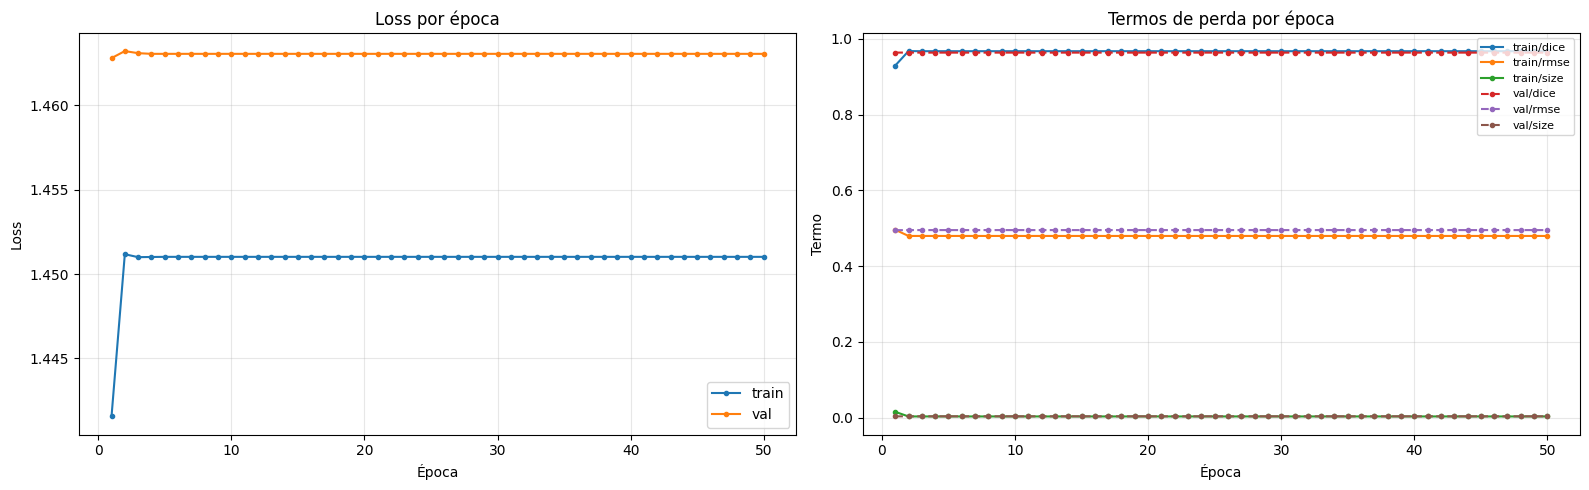

In [40]:
epochs = list(range(1, NUM_EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(epochs, history["train_loss"], label="train", marker="o", ms=3)
axes[0].plot(epochs, history["val_loss"], label="val", marker="o", ms=3)
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss por época")
axes[0].legend()
axes[0].grid(alpha=0.3)

for name, vals in history["train_terms"].items():
    axes[1].plot(epochs, vals, label=f"train/{name}", marker="o", ms=3)
for name, vals in history["val_terms"].items():
    axes[1].plot(epochs, vals, label=f"val/{name}", marker="o", ms=3, linestyle="--")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Termo")
axes[1].set_title("Termos de perda por época")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Validações finais

In [41]:
import math

tl = history["train_loss"]
vl = history["val_loss"]

assert len(tl) == NUM_EPOCHS, "Deveria haver 50 épocas de treino"
assert len(vl) == NUM_EPOCHS, "Deveria haver 50 épocas de validação"
assert all(math.isfinite(x) for x in tl), "train_loss não é finita!"
assert all(math.isfinite(x) for x in vl), "val_loss não é finita!"

print(f"OK: todas as losses são finitas ({NUM_EPOCHS} épocas).")
print(f"train_loss: {tl[0]:.4f} -> {tl[-1]:.4f}")
print(f"val_loss:   {vl[0]:.4f} -> {vl[-1]:.4f}")

if tl[-1] < tl[0]:
    print(f"OK: loss de treino decresceu {tl[0]:.4f} -> {tl[-1]:.4f}")
else:
    print(f"[info] train_loss não decresceu ({tl[0]:.4f} -> {tl[-1]:.4f}) - verifique o learning rate")

print("\nTREINAMENTO COMPLETO COM TODAS AS IMAGENS!")
print(f"Melhor val_loss: {min(vl):.4f} (época {vl.index(min(vl)) + 1})")

OK: todas as losses são finitas (50 épocas).
train_loss: 1.4416 -> 1.4510
val_loss:   1.4628 -> 1.4630
[info] train_loss não decresceu (1.4416 -> 1.4510) - verifique o learning rate

TREINAMENTO COMPLETO COM TODAS AS IMAGENS!
Melhor val_loss: 1.4628 (época 1)


## 11. Visualização - predições em imagens de validação

2026-08-10 12:24:14.473 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-10 12:24:14.484 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (1, 1, 1000, 1000)


2026-08-10 12:24:14.520 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-10 12:24:14.532 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (1, 1, 1000, 1000)
2026-08-10 12:24:14.568 | DEBUG    | src.pipeline.steps.inference.marker_step:forward:117 - [MarkerStep] Generated markers with shape (1, 1, 1000, 1000)
2026-08-10 12:24:14.579 | DEBUG    | src.pipeline.steps.inference.frozen_segmentation_step:forward:110 - [FrozenSegmentationStep] Generated segmentation with shape (1, 1, 1000, 1000)


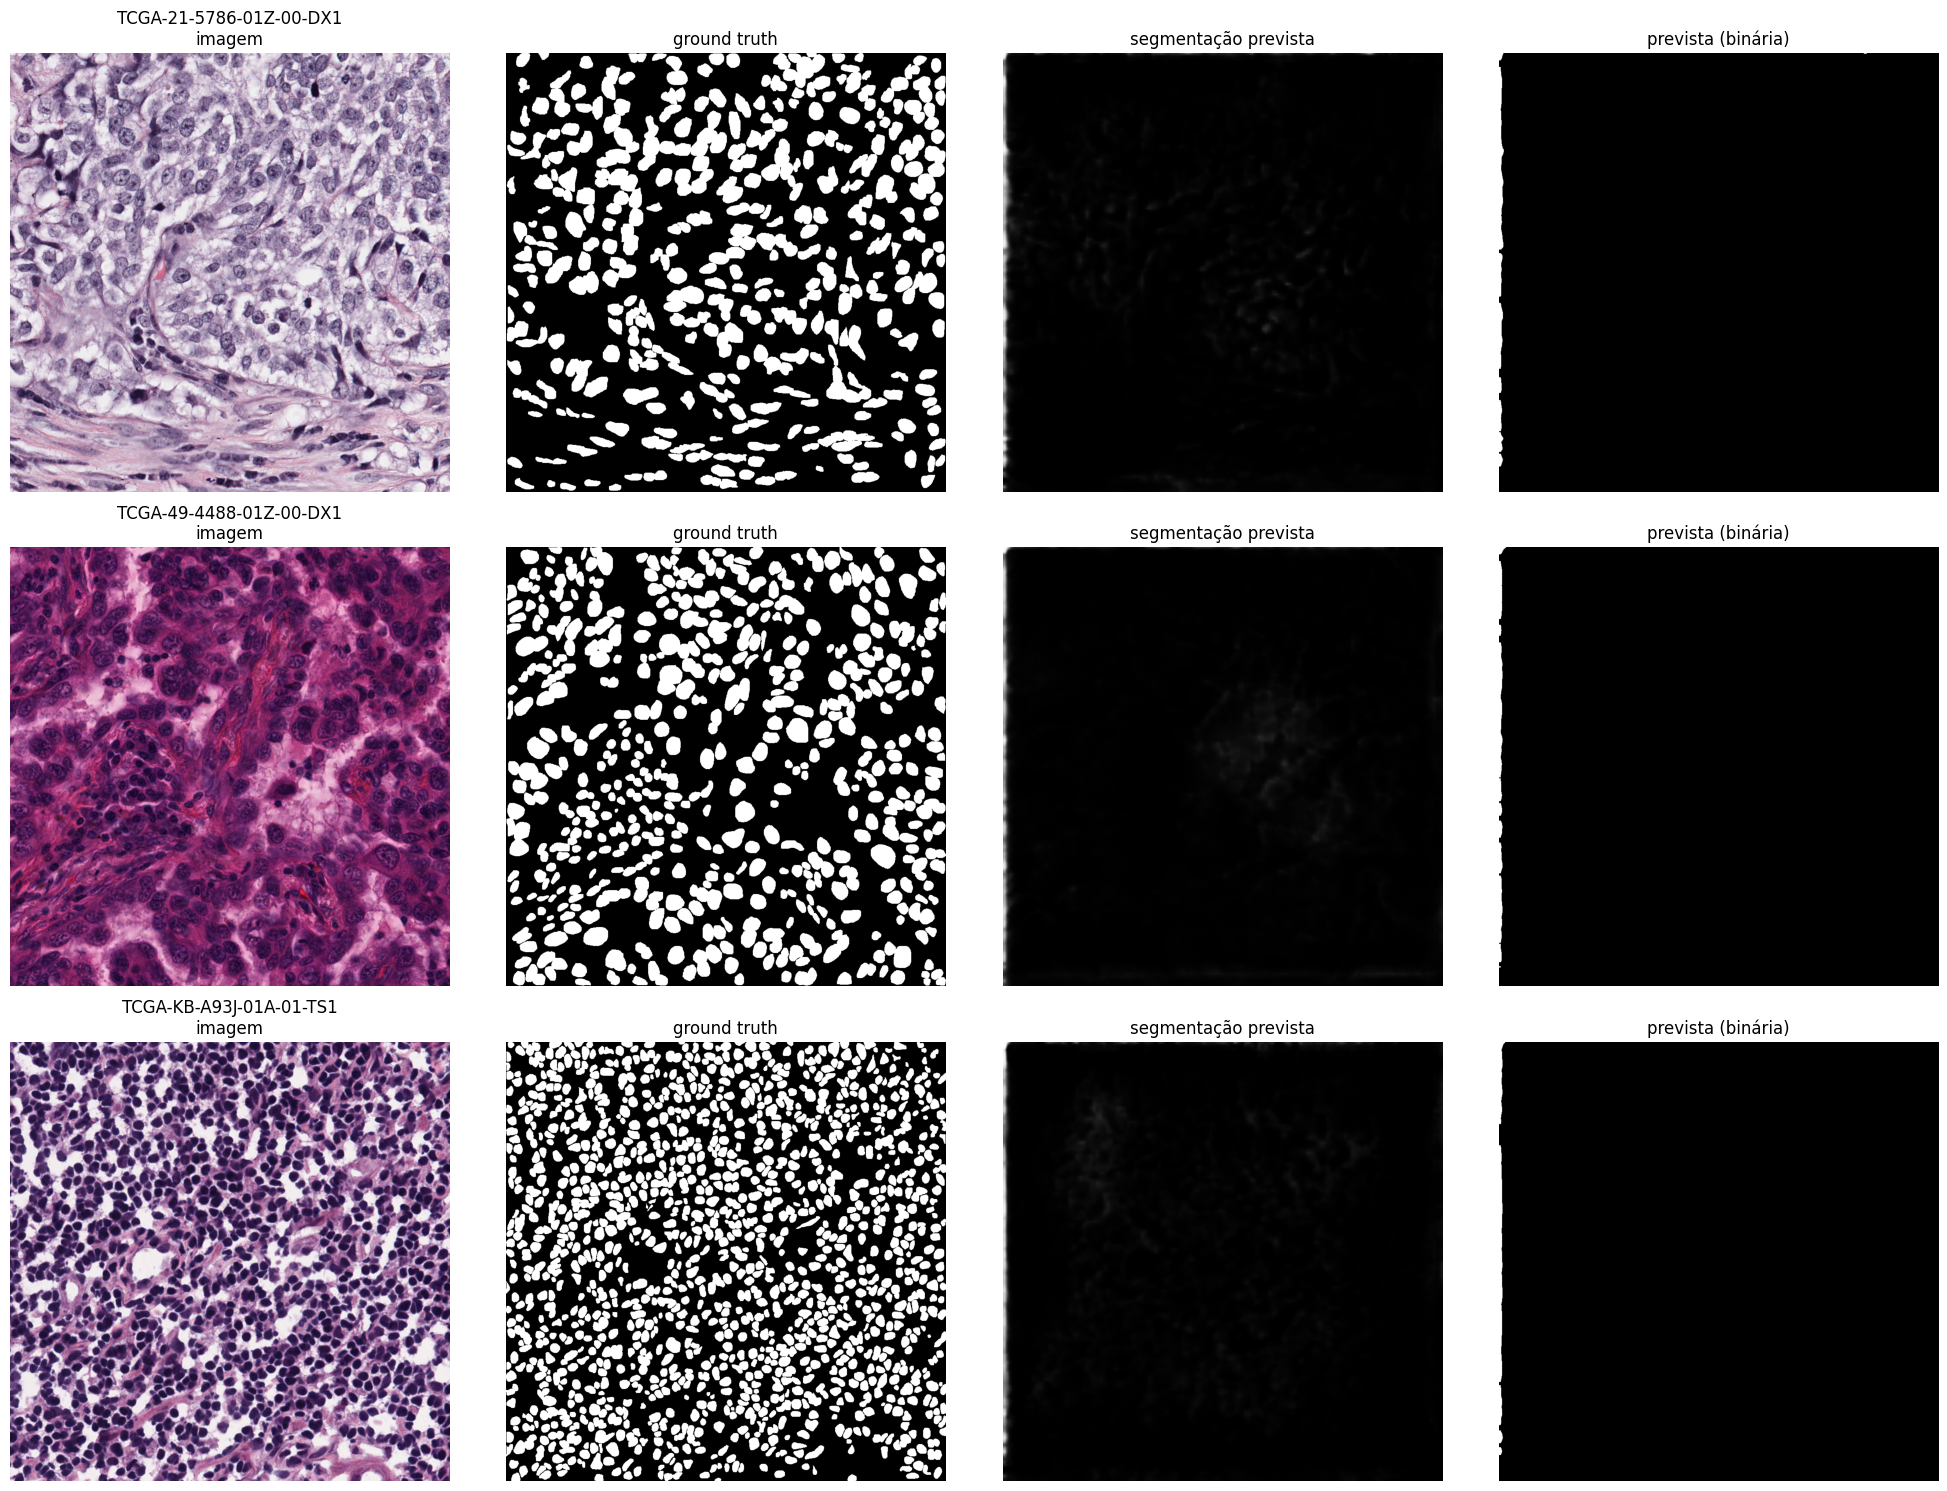

In [42]:
def tensor_to_np(t):
    return t.detach().cpu().numpy()[0, 0]


N = min(3, len(val_batches))
fig, axes = plt.subplots(N, 4, figsize=(20, 5 * N))
if N == 1:
    axes = axes[None, :]

for row, batch in enumerate(val_batches[:N]):
    with torch.no_grad():
        out = training_pipeline.run(batch, verbose=False)

    img = batch["image"][0].permute(1, 2, 0).numpy()
    if img.max() > 1.0:
        img = img / 255.0
    gt = tensor_to_np(batch["ground_truth"])
    seg = tensor_to_np(out["segmentation"])

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"{batch['id']}\nimagem")
    axes[row, 1].imshow(gt, cmap="gray")
    axes[row, 1].set_title("ground truth")
    axes[row, 2].imshow(seg, cmap="gray")
    axes[row, 2].set_title("segmentação prevista")
    axes[row, 3].imshow(seg > 0.5, cmap="gray")
    axes[row, 3].set_title("prevista (binária)")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

## 12. Salvar checkpoint

Salva os pesos da **MarkerNet treinada** em `checkpoints/marker_net_trained.pt` para uso posterior em inferência.

In [43]:
os.makedirs("checkpoints", exist_ok=True)
ckpt_path = os.path.join("checkpoints", "marker_net_trained.pt")

torch.save(
    {
        "state_dict": marker_net.state_dict(),
        "config": UNET_CONFIG,
        "epochs": NUM_EPOCHS,
        "size": train_batches[0]["image"].shape[-2],  # altura dos batches (imagens quadradas, ex.: 1000)
        "best_val_loss": min(history["val_loss"]),
    },
    ckpt_path,
)
print(f"Checkpoint salvo em {ckpt_path}")
print("Arquivos em checkpoints/:", os.listdir("checkpoints"))

Checkpoint salvo em checkpoints/marker_net_trained.pt
Arquivos em checkpoints/: ['marker_net_trained.pt', 'ScribblePrompt_unet_v1_nf192_res128.pt']
